# Nu-classifier dataloader inspection

Verifies that the dataloader pipeline (normalisation, augmentation, amp-clip) behaves as expected.
Groups events by particle type: **muatm** (0), **nuatm** (1), **nue2** (2), **exp** (-1).

Sections:
1. Raw per-hit feature distributions (original units, no normalisation)
2. Normalised + amp-clipped distributions (what the model processes)
3. Event multiplicity — `n_hits` per event
4. Per-event mean and std of features
5. x–y hit density (spatial sanity check)

In [1]:
print('test')

test


In [2]:
import os, sys
from pathlib import Path
import logging
import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.WARNING)  # suppress dataset INFO spam

ROOT = Path('..').resolve()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [48]:
# ── Configurable parameters ──────────────────────────────────────────────────
NPY_DIR      = 'data_manager/datasets/nu_classifier_dataset_h5s0_thr0.8'
N_MC_EVENTS  = 100_000   # MC events to load  (~60 batches at bs//2 = 256)
N_EXP_EVENTS = None     # None = all available (~39 k)
BATCH_SIZE   = 512      # as in trainer config
MAX_HITS     = 500
AMP_CLIP_RAW = 100.0    # model.amp_clip in original PE units
N_BATCHES_MC = 300       # how many MC batches to collect
SEED         = 42
DEVICE       = 'cpu'

In [49]:
# ── Normalisation + augmentation config ─────────────────────────────────────
with open('data_manager/stats_dict/default_mc.yaml') as _f:
    norm_cfg = yaml.safe_load(_f)

MEANS = np.array(norm_cfg['means'], dtype=np.float32)
STDS  = np.array(norm_cfg['stds'],  dtype=np.float32)
FEAT  = norm_cfg.get('feature_names', ['Q', 't', 'x', 'y', 'z'])

AUG_CFG = {'noise_std': [0.05, 5.0, 1.0, 1.0, 2.0], 'rotation_enabled': True}

# amp_clip converted to normalised space (applied by AttentionFeatureExtractor)
AMP_CLIP_NORM = float((AMP_CLIP_RAW - MEANS[0]) / STDS[0])

print(f'Features : {FEAT}')
print(f'Means    : {MEANS.tolist()}')
print(f'Stds     : {STDS.tolist()}')
print(f'amp_clip : {AMP_CLIP_RAW:.0f} PE  ->  {AMP_CLIP_NORM:.4f} (normalised)')

Features : ['amplitude', 'time', 'x', 'y', 'z']
Means    : [2.0, 0.0, 0.0, 0.0, 0.0]
Stds     : [60.0, 1370.0, 40.0, 40.0, 150.0]
amp_clip : 100 PE  ->  1.6333 (normalised)


In [50]:
# ── Datasets and dataloaders ─────────────────────────────────────────────────
from src.data.nu_classifier_dataset import (
    NuClassifierNpyDataset,
    NuClassifierExpNpyDataset,
    create_nu_classifier_dataloader,
)

mc_ds  = NuClassifierNpyDataset(npy_dir=NPY_DIR, max_hits=MAX_HITS,
                                 max_events=N_MC_EVENTS, seed=SEED)
exp_ds = NuClassifierExpNpyDataset(npy_dir=NPY_DIR, max_hits=MAX_HITS,
                                    max_events=N_EXP_EVENTS, seed=SEED)

_bs = BATCH_SIZE // 2   # trainer uses bs//2 per domain
_kw = dict(shuffle_batch=False, device=DEVICE, num_workers=0, pin_memory=False)

mc_dl_raw  = create_nu_classifier_dataloader(
    mc_ds,  _bs, shuffle=False,
    normalization_config=None,     augmentation_config=None,    **_kw)
mc_dl_norm = create_nu_classifier_dataloader(
    mc_ds,  _bs, shuffle=True,
    normalization_config=norm_cfg, augmentation_config=AUG_CFG, **_kw)
exp_dl_raw  = create_nu_classifier_dataloader(
    exp_ds, _bs, shuffle=False,
    normalization_config=None,     augmentation_config=None,    **_kw)
exp_dl_norm = create_nu_classifier_dataloader(
    exp_ds, _bs, shuffle=True,
    normalization_config=norm_cfg, augmentation_config=AUG_CFG, **_kw)

print(f'MC  dataset : {len(mc_ds):,} events  |  {len(mc_dl_raw):,} batches @ bs={_bs}')
print(f'Exp dataset : {len(exp_ds):,} events  |  {len(exp_dl_raw):,} batches @ bs={_bs}')

MC  dataset : 100,000 events  |  391 batches @ bs=256
Exp dataset : 39,130 events  |  153 batches @ bs=256


In [51]:
# ── Collect batches ──────────────────────────────────────────────────────────
def collect_batches(dl, n_max=None):
    out = []
    for i, b in enumerate(dl):
        if n_max is not None and i >= n_max:
            break
        out.append({k: (v.clone() if isinstance(v, torch.Tensor) else v)
                    for k, v in b.items()})
    return out

print('Collecting batches ...')
mc_raw  = collect_batches(mc_dl_raw,  N_BATCHES_MC)
mc_norm = collect_batches(mc_dl_norm, N_BATCHES_MC)
exp_raw  = collect_batches(exp_dl_raw)
exp_norm = collect_batches(exp_dl_norm)
print(f'  MC  raw / norm : {len(mc_raw)} / {len(mc_norm)} batches')
print(f'  Exp raw / norm : {len(exp_raw)} / {len(exp_norm)} batches')

  MC  raw / norm : 300 / 300 batches
  Exp raw / norm : 153 / 153 batches


In [52]:
# ── Apply amp-clip (replicates AttentionFeatureExtractor._clip_amplitude) ────
def apply_amp_clip(batches, clip):
    out = []
    for b in batches:
        b2 = {k: (v.clone() if isinstance(v, torch.Tensor) else v)
              for k, v in b.items()}
        mask = b2['mask']                         # [B, T] bool, True = valid hit
        amp  = b2['features'][..., 0].clone()
        b2['features'][..., 0] = torch.where(mask, amp.clamp(max=clip), amp)
        out.append(b2)
    return out

mc_clip  = apply_amp_clip(mc_norm,  AMP_CLIP_NORM)
exp_clip = apply_amp_clip(exp_norm, AMP_CLIP_NORM)

# ── Particle type labels ─────────────────────────────────────────────────────
# 0 = muatm_2020  |  1 = nuatm_2020  |  2 = nue2_2020  |  -1 = exp (sentinel)
PT_NAMES  = {0: 'muatm', 1: 'nuatm', 2: 'nue2', -1: 'exp'}
PT_COLORS = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green', -1: 'tab:red'}
PT_ORDER  = [0, 1, 2, -1]

In [53]:
# ── Unpack helpers ────────────────────────────────────────────────────────────
def unpack(batches):
    """Extract valid (non-padded) hits.
    Returns hits[N,5], hit_pts[N], ev_pts[M], ev_lens[M]."""
    hl, hpl, epl, ll = [], [], [], []
    for b in batches:
        F = b['features'].numpy()        # [B, T, 5]
        L = b['lengths'].numpy()         # [B]
        P = b['particle_types'].numpy()  # [B]
        for i in range(len(L)):
            n = int(L[i])
            hl.append(F[i, :n])
            hpl.append(np.full(n, int(P[i]), dtype=np.int32))
            epl.append(int(P[i]))
            ll.append(n)
    return (
        np.concatenate(hl),
        np.concatenate(hpl),
        np.array(epl, dtype=np.int32),
        np.array(ll,  dtype=np.int32),
    )

def ev_stats(batches):
    """Per-event mean/std. Returns means[M,5], stds[M,5], ev_pts[M]."""
    ml, sl, pl = [], [], []
    for b in batches:
        F = b['features'].numpy()
        L = b['lengths'].numpy()
        P = b['particle_types'].numpy()
        for i in range(len(L)):
            n  = int(L[i])
            ev = F[i, :n]
            ml.append(ev.mean(axis=0))
            sl.append(ev.std(axis=0) if n > 1 else np.zeros(5, dtype=np.float32))
            pl.append(int(P[i]))
    return np.array(ml), np.array(sl), np.array(pl, dtype=np.int32)

In [83]:
# ── Unpack all four collections ──────────────────────────────────────────────
mc_hr,  mc_hpr,  mc_epr,  mc_elr  = unpack(mc_raw)
mc_hc,  mc_hpc,  mc_epc,  mc_elc  = unpack(mc_clip)
ex_hr,  ex_hpr,  ex_epr,  ex_elr  = unpack(exp_raw)
ex_hc,  ex_hpc,  ex_epc,  ex_elc  = unpack(exp_clip)

mc_rmn, mc_rsd, mc_reps = ev_stats(mc_raw)
ex_rmn, ex_rsd, ex_reps = ev_stats(exp_raw)
mc_mn, mc_sd, mc_eps = ev_stats(mc_clip)
ex_mn, ex_sd, ex_eps = ev_stats(exp_clip)

# merged (MC + Exp)
H_r  = np.concatenate([mc_hr, ex_hr]);  HP_r = np.concatenate([mc_hpr, ex_hpr])
H_c  = np.concatenate([mc_hc, ex_hc]);  HP_c = np.concatenate([mc_hpc, ex_hpc])
EL_r = np.concatenate([mc_elr, ex_elr]); EP_r = np.concatenate([mc_epr, ex_epr])
MNR   = np.concatenate([mc_rmn, ex_rmn]);  SDR   = np.concatenate([mc_rsd, ex_rsd])
EP_rs = np.concatenate([mc_reps, ex_reps])
MN   = np.concatenate([mc_mn, ex_mn]);  SD   = np.concatenate([mc_sd, ex_sd])
EP_s = np.concatenate([mc_eps, ex_eps])

print(f'  {"group":8s}  {"events":>8s}  {"hits":>10s}  {"mean nhits":>10s}')
for g in PT_ORDER:
    n_ev = (EP_r == g).sum();  n_h = (HP_r == g).sum()
    if n_ev:
        print(f'  {PT_NAMES[g]:8s}  {n_ev:8,}  {n_h:10,}  {n_h/n_ev:10.1f}')

  group       events        hits  mean nhits
  muatm       38,218     365,155         9.6
  nuatm       19,205     124,581         6.5
  nue2        19,377     248,445        12.8
  exp         39,130     418,629        10.7


## 1. Raw per-hit feature distributions
Original units, no normalisation, no augmentation.  
Q is shown on a **log x-axis** (spans orders of magnitude).

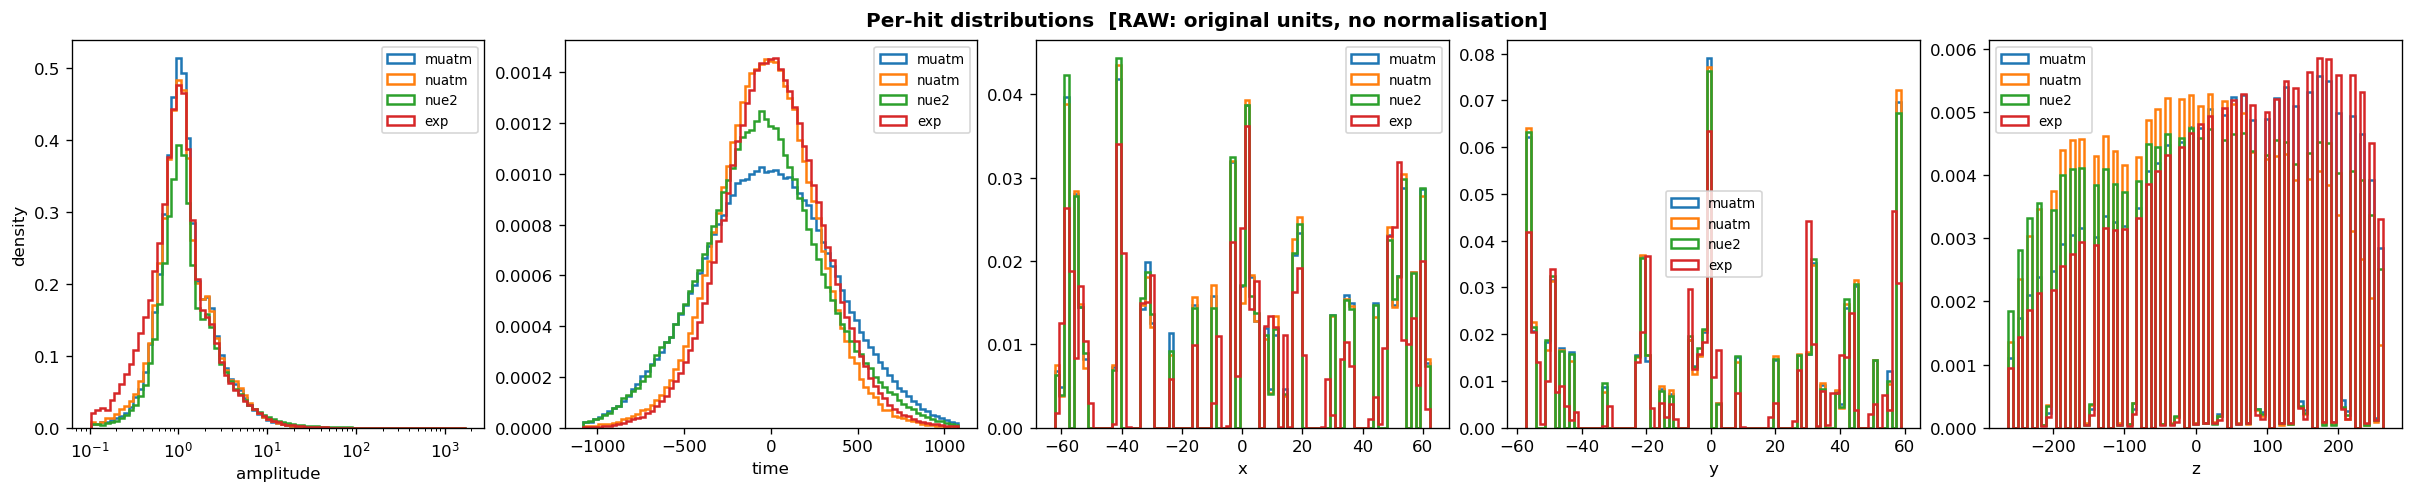

In [95]:
def plot_hit_dists(H, HP, title, bins=80, log_q=False):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4), constrained_layout=True)
    fig.suptitle(title, fontsize=12, fontweight='bold')
    for fi in range(5):
        ax    = axes[fi]
        v_all = H[:, fi]
        lo, hi = np.percentile(v_all, [0.1, 99.9])
        if fi == 0 and log_q:
            lo = max(lo, 1e-3)
            ba = np.geomspace(lo, hi, bins)
            ax.set_xscale('log')
        else:
            ba = np.linspace(lo, hi, bins)
        for g in PT_ORDER:
            m = HP == g
            if m.sum() < 10:
                continue
            v = v_all[m]; v = v[(v >= lo) & (v <= hi)]
            ax.hist(v, bins=ba, density=True, histtype='step',
                    label=PT_NAMES[g], color=PT_COLORS[g], lw=1.5)
        ax.set_xlabel(FEAT[fi])
        if fi == 0:
            ax.set_ylabel('density')
        ax.legend(fontsize=8)
    return fig

fig1 = plot_hit_dists(
    H_r, HP_r,
    'Per-hit distributions  [RAW: original units, no normalisation]',
    log_q=True,
)
plt.savefig('notebooks/fig_hits_raw.png', bbox_inches='tight')
plt.show()

In [91]:
mc_hr[:,1].min()

np.float32(-1501.011)

In [78]:
print(mc_hr[mc_hpr == 0, 1].std(axis=0), ex_hr[:,1].std(axis=0))

385.5846 288.28967


## 2. Normalised + amp-clipped per-hit distributions
What the model actually processes: `(x - mean) / std` then Q clipped at `AMP_CLIP_NORM`.  
Augmentation (rotation + noise) is enabled — matches training conditions.

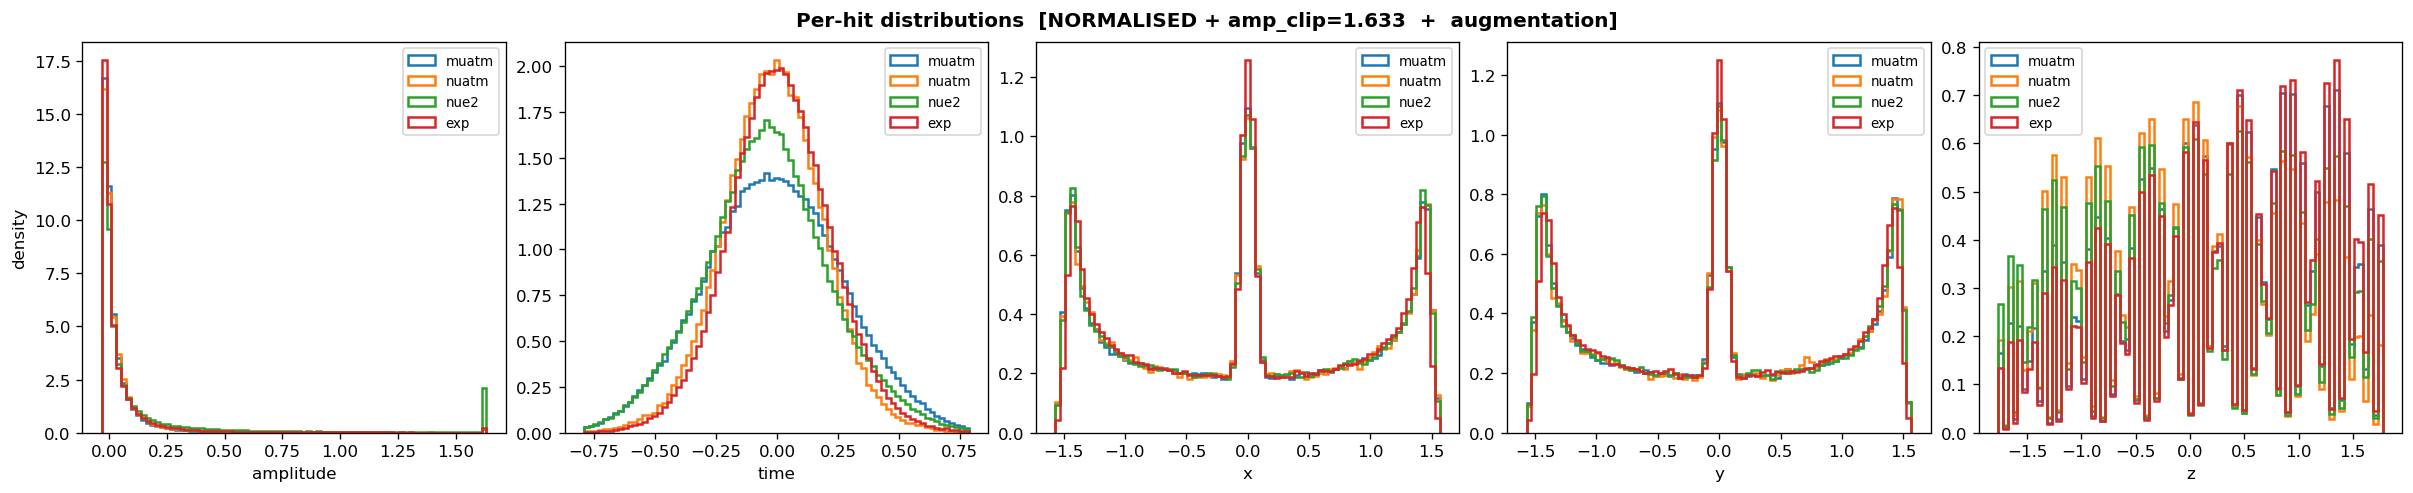

In [96]:
fig2 = plot_hit_dists(
    H_c, HP_c,
    f'Per-hit distributions  [NORMALISED + amp_clip={AMP_CLIP_NORM:.3f}  +  augmentation]',
    log_q=False,
)
plt.savefig('notebooks/fig_hits_normalised.png', bbox_inches='tight')
plt.show()

In [77]:
print(mc_hc[mc_hpc == 0, 1].std(axis=0), ex_hc[:,1].std(axis=0))

0.28170973 0.21046242


## 3. Event multiplicity — n_hits per event
After sig-noise filtering (thr=0.8) and max_hits truncation.

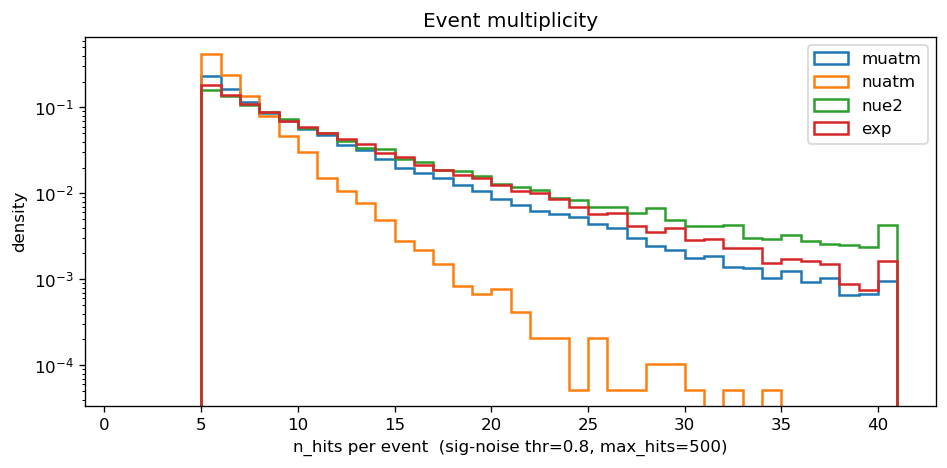

Median n_hits per group:
  muatm   : median=7  p95=21
  nuatm   : median=6  p95=10
  nue2    : median=9  p95=34
  exp     : median=8  p95=24


In [97]:
fig3, ax = plt.subplots(figsize=(8, 4))
hi_n = int(np.percentile(EL_r, 99)) + 1
ba_n = np.arange(1, hi_n + 1)
for g in PT_ORDER:
    m = EP_r == g
    if m.sum() < 5:
        continue
    ax.hist(EL_r[m], bins=ba_n, density=True, histtype='step',
            label=PT_NAMES[g], color=PT_COLORS[g], lw=1.5)
ax.set_yscale('log')
ax.set_xlabel('n_hits per event  (sig-noise thr=0.8, max_hits=500)')
ax.set_ylabel('density')
ax.legend()
ax.set_title('Event multiplicity')
plt.tight_layout()
plt.savefig('notebooks/fig_nhits.png', bbox_inches='tight')
plt.show()

print('Median n_hits per group:')
for g in PT_ORDER:
    m = EP_r == g
    if m.sum():
        print(f'  {PT_NAMES[g]:8s}: median={np.median(EL_r[m]):.0f}  '
              f'p95={np.percentile(EL_r[m], 95):.0f}')

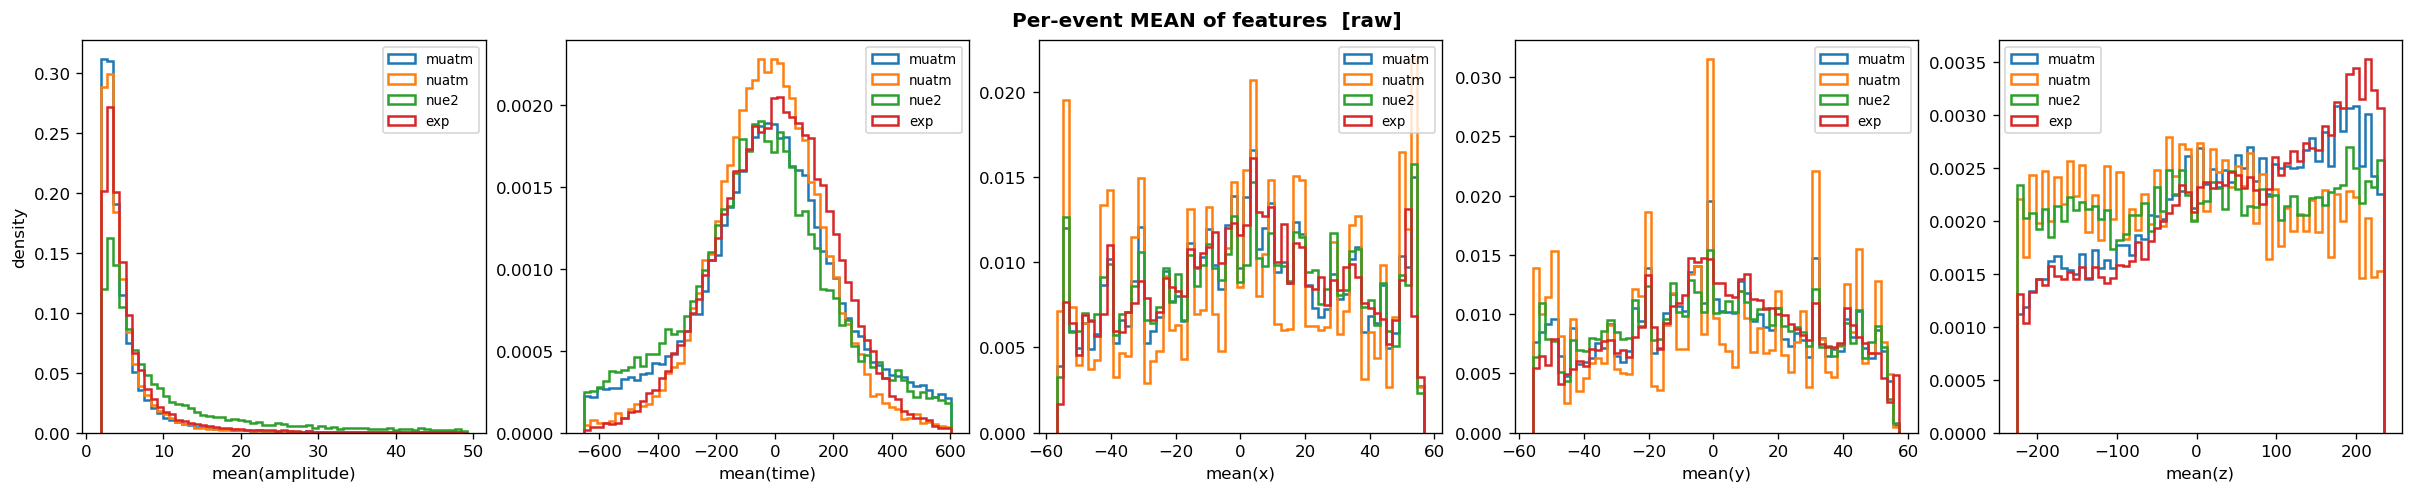

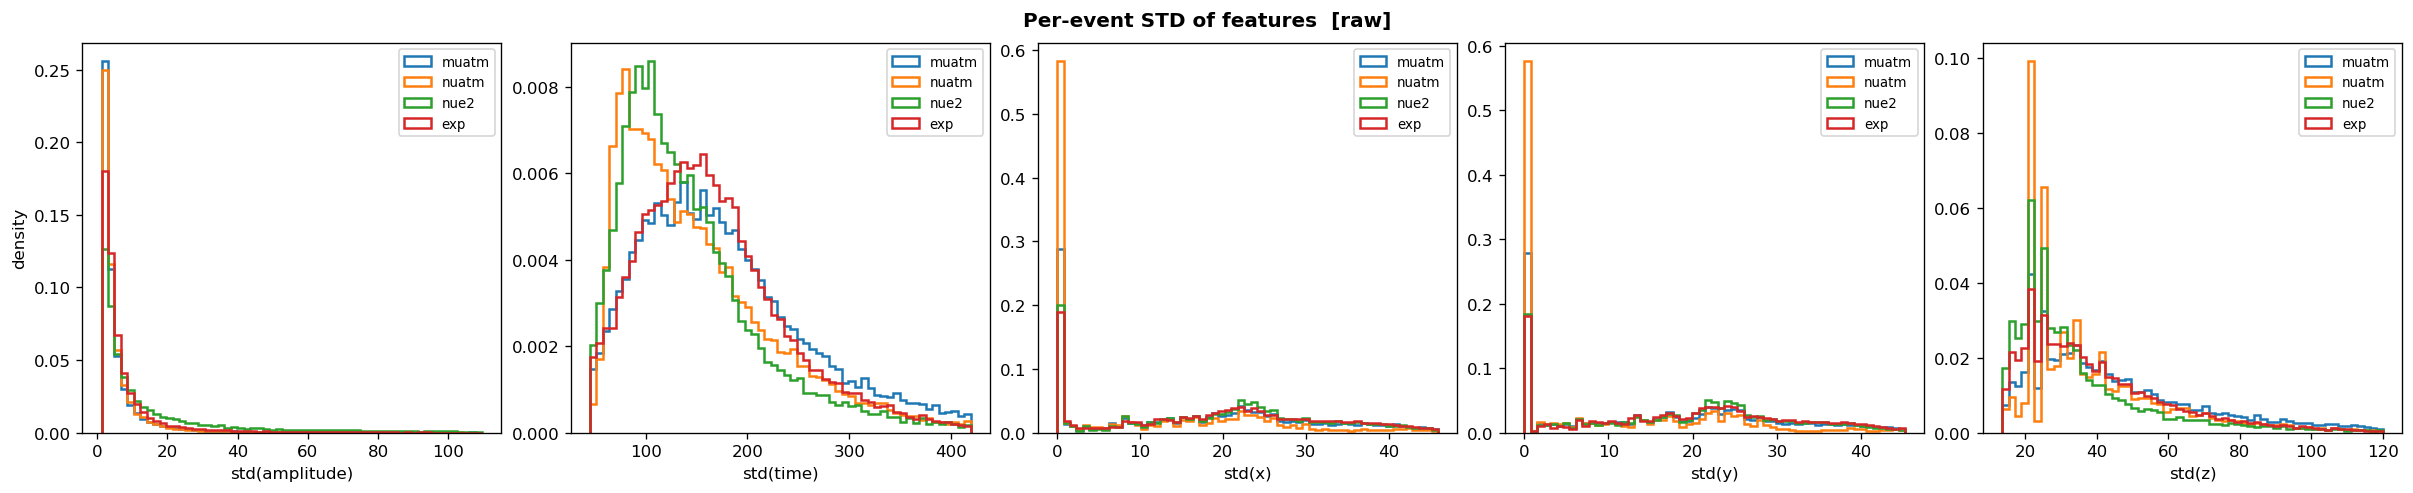

In [98]:
def plot_ev_stat(vals, pts, row_title, bins=60, label='mean'):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4), constrained_layout=True)
    fig.suptitle(row_title, fontsize=12, fontweight='bold')
    for fi in range(5):
        ax    = axes[fi]
        v_all = vals[:, fi]
        lo, hi = np.percentile(v_all, [2, 98])
        ba = np.linspace(lo, hi, bins)
        for g in PT_ORDER:
            m = pts == g
            if m.sum() < 5:
                continue
            v = v_all[m]; v = v[(v >= lo) & (v <= hi)]
            ax.hist(v, bins=ba, density=True, histtype='step',
                    label=PT_NAMES[g], color=PT_COLORS[g], lw=1.5)
        ax.set_xlabel(f'{label}({FEAT[fi]})')
        if fi == 0:
            ax.set_ylabel('density')
        ax.legend(fontsize=8)
    return fig

fig4 = plot_ev_stat(MNR, EP_rs,
    'Per-event MEAN of features  [raw]')
plt.savefig('notebooks/fig_ev_mean.png', bbox_inches='tight')
plt.show()

fig5 = plot_ev_stat(SDR, EP_rs,
    'Per-event STD of features  [raw]', label='std')
plt.savefig('notebooks/fig_ev_std.png', bbox_inches='tight')
plt.show()

## 4.2 Per-event mean and std of features (normalised + clipped)
Mean and std computed over the valid hits of each event.  
Differences here indicate systematic offsets between domains even after normalisation.

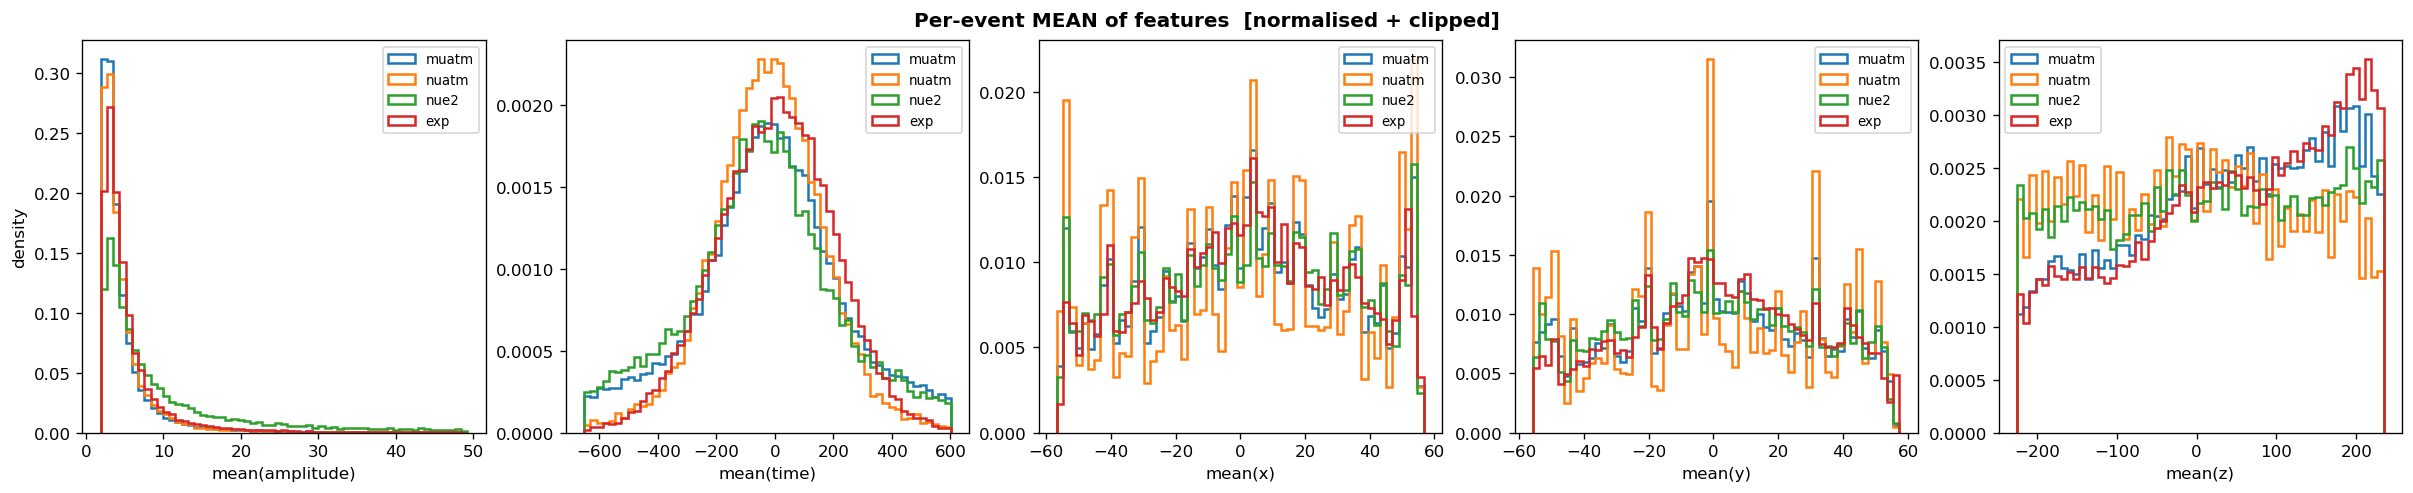

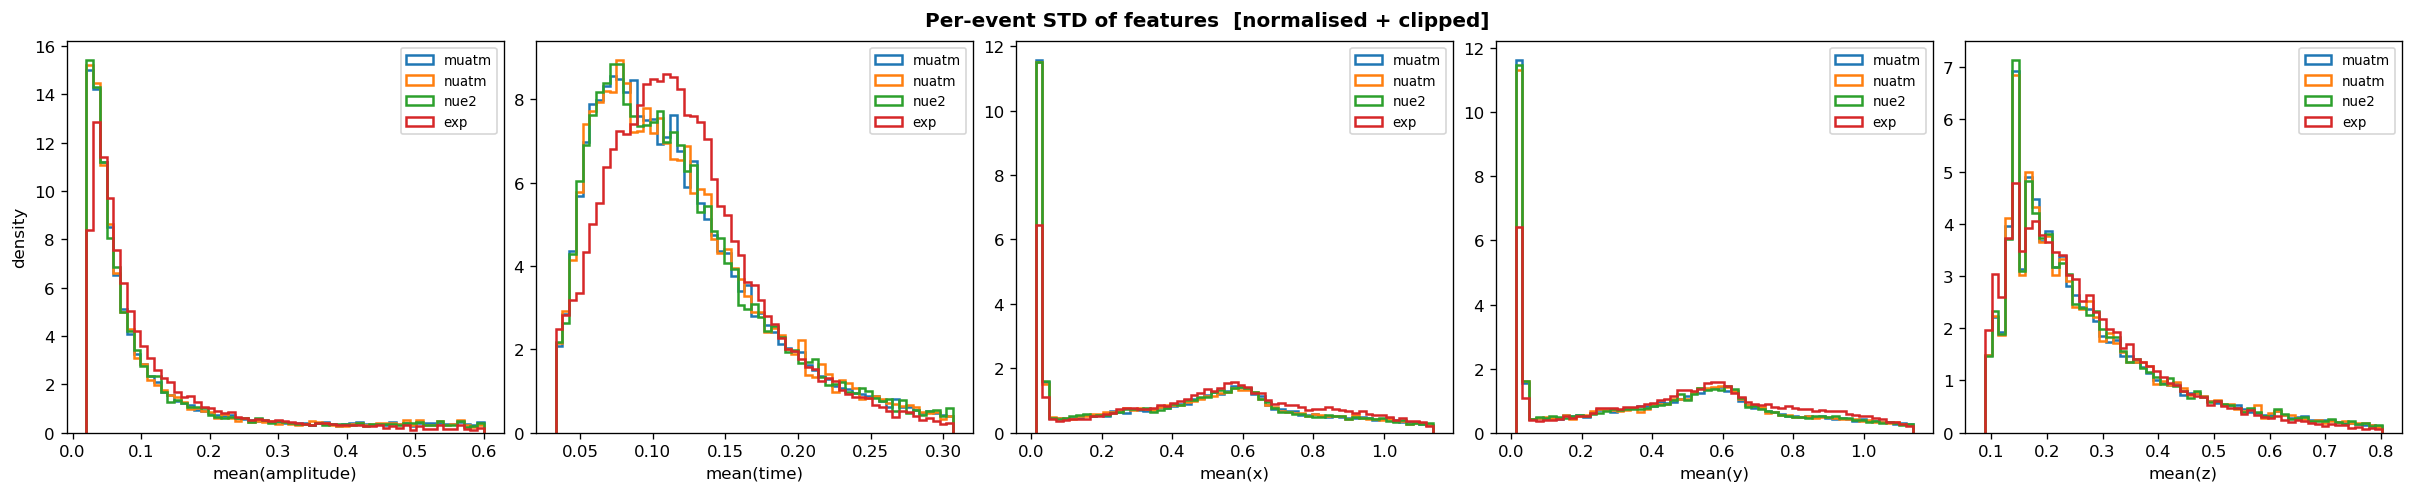

In [99]:
def plot_ev_stat(vals, pts, row_title, bins=60):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4), constrained_layout=True)
    fig.suptitle(row_title, fontsize=12, fontweight='bold')
    for fi in range(5):
        ax    = axes[fi]
        v_all = vals[:, fi]
        lo, hi = np.percentile(v_all, [2, 98])
        ba = np.linspace(lo, hi, bins)
        for g in PT_ORDER:
            m = pts == g
            if m.sum() < 5:
                continue
            v = v_all[m]; v = v[(v >= lo) & (v <= hi)]
            ax.hist(v, bins=ba, density=True, histtype='step',
                    label=PT_NAMES[g], color=PT_COLORS[g], lw=1.5)
        ax.set_xlabel(f'mean({FEAT[fi]})')
        if fi == 0:
            ax.set_ylabel('density')
        ax.legend(fontsize=8)
    return fig

fig4 = plot_ev_stat(MNR, EP_rs,
    'Per-event MEAN of features  [normalised + clipped]')
plt.savefig('notebooks/fig_ev_mean.png', bbox_inches='tight')
plt.show()

fig5 = plot_ev_stat(SD, EP_rs,
    'Per-event STD of features  [normalised + clipped]')
plt.savefig('notebooks/fig_ev_std.png', bbox_inches='tight')
plt.show()

## 5. Hit spatial distribution: x–y density
Hex-bin density plot of all hit (x, y) coordinates in raw metre units.  
Shape differences would suggest a geometric MC/Exp mismatch.

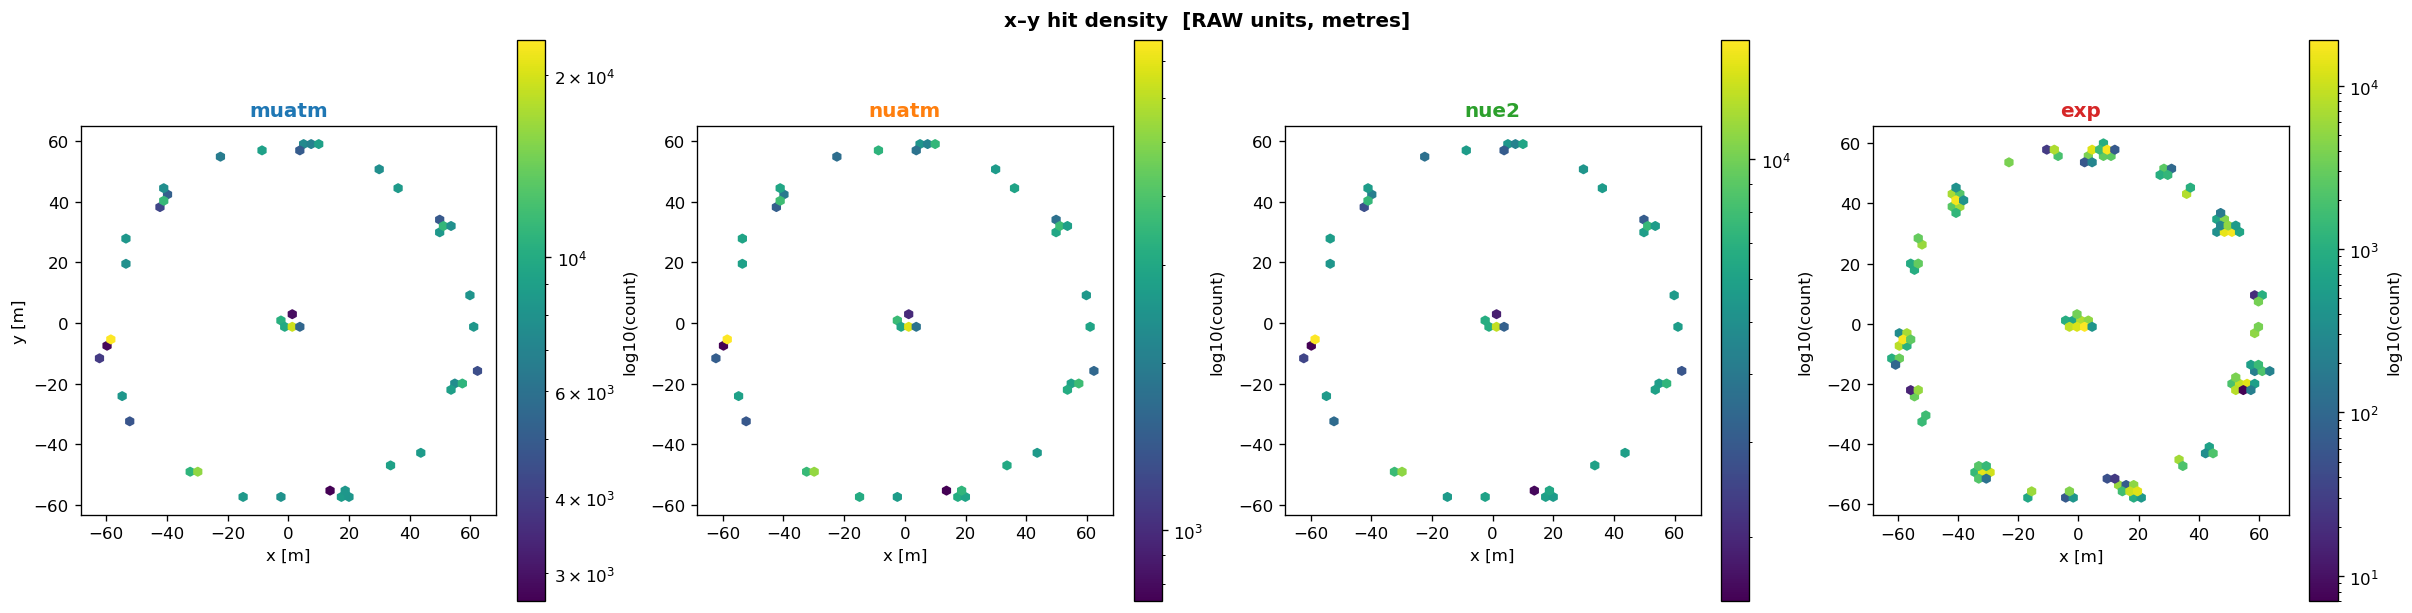

In [81]:
active = [g for g in PT_ORDER if (HP_r == g).sum() >= 50]
fig6, axes = plt.subplots(1, len(active),
                           figsize=(5 * len(active), 5),
                           constrained_layout=True)
fig6.suptitle('x–y hit density  [RAW units, metres]', fontsize=12, fontweight='bold')
if len(active) == 1:
    axes = [axes]

for ax, g in zip(axes, active):
    m  = HP_r == g
    hb = ax.hexbin(H_r[m, 2], H_r[m, 3],
                   gridsize=50, bins='log', cmap='viridis')
    plt.colorbar(hb, ax=ax, label='log10(count)')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]' if g == active[0] else '')
    ax.set_title(PT_NAMES[g], color=PT_COLORS[g], fontweight='bold')
    ax.set_aspect('equal')

plt.savefig('notebooks/fig_xy_density.png', bbox_inches='tight')
plt.show()